In [35]:
# Model Training

In [36]:
# Restaurant Reviews Prediction System (sentiment analysis)

In [37]:
# Normally, a lot of businesses are remained as failures due to lack of profit, lack of proper
# improvement measures. Mostly, restaurant owners face a lot of difficulties to improve their productivity.
# This project really helps
# those who want to increase their productivity, which in turn increases their business profits.
# This is the main objective of this project.

# What the project does is that the restaurant owner gets to know about drawbacks of his restaurant
# such as most disliked food items of his restaurant by customer’s text review which is processed with ML
# classification algorithm(Naive Bayes)

In [38]:

# step - 1 >>>>> import packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    r"r_data.tsv",
    delimiter='\t'
)

In [4]:
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
1381,clean,1
1382,less,0
1383,clean,1
1384,less,0


In [5]:
df.shape

(1386, 2)

In [6]:
df.dtypes

Review      str
Liked     int64
dtype: object

In [7]:
# 0 > Bad
# 1 > Good

In [8]:
# EDA

In [9]:
s1 = df['Liked'].value_counts()

<Axes: xlabel='Liked'>

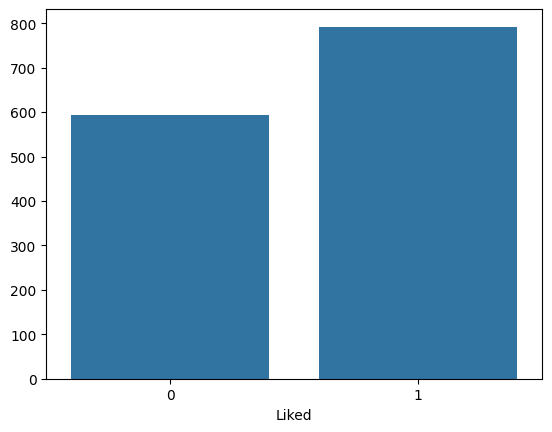

In [10]:
sns.barplot(x=s1.index, y=s1.values)

In [11]:
# ML preprocessing

In [12]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re

In [13]:
# Text
# LowerCase
# Remove special character and digits
# Tokenization >>>> Breakdown the sentence#
# Remove stopwords >>>> Stopwords are common words >>>> a,a,the,to,and,on
# Stemming >>>> To get basic or root word / to remove suffixes >>>> Affected/Affecting >>>> Affect
# Conver List to original String

In [14]:
s_list = stopwords.words('english')

In [15]:
len(s_list)

198

In [16]:
from shlex import join


corpus = []
for i in df['Review']:
    i = i.lower()
    mystr = re.sub(r'[^A-Za-z\s]', '', i)   # remove special chars and numbers
    list1 = mystr.split()
    list2 = [i for i in list1 if i not in s_list]
    ps = PorterStemmer()
    list3 = [ps.stem(i) for i in list2]
    final = ' '.join(list3)
    corpus.append(final)
print(corpus[:5])

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price']


In [17]:
# # Vectorization

# From the cleaned dataset, potential features are extracted and are converted to numerical format.
# The vectorization techniques are used to convert textual data to numerical format.
# Using vectorization, a matrix is created where each column represents a feature and each row
# represents an individual review.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X = cv.fit_transform(corpus).toarray()
y = df['Liked']

In [19]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1386, 1612))

In [20]:
import pickle

In [21]:
with open('cvmodel', 'wb') as f:
    pickle.dump(cv, f)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [23]:
# Model Training

In [24]:
# Fitting Naive Bayes to the Training set
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
classifier1 = MultinomialNB(alpha=0.1)
classifier1.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier1.predict(X_test)

# Making the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy, Precision and Recall
print('Classification Report\n', classification_report(y_test, y_pred))
score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)
print("\n")
print("Accuracy is :", round(score1*100, 2), "%")
print("Precision is :", round(score2, 2))
print("Recall is :", round(score3, 2))

Confusion Matrix:
 [[ 90  30]
 [ 25 133]]
Classification Report
               precision    recall  f1-score   support

           0       0.78      0.75      0.77       120
           1       0.82      0.84      0.83       158

    accuracy                           0.80       278
   macro avg       0.80      0.80      0.80       278
weighted avg       0.80      0.80      0.80       278



Accuracy is : 80.22 %
Precision is : 0.82
Recall is : 0.84


In [25]:
# Logistic Regression

# Fitting Logistic Regression to the Training set
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn import linear_model
classifier2 = linear_model.LogisticRegression(C=1.5)
classifier2.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier2.predict(X_test)

# Making the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy, Precision and Recall
print('Classification Report\n', classification_report(y_test, y_pred))
score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)
print("\n")
print("Accuracy is ", round(score1*100, 2), "%")
print("Precision is ", round(score2, 2))
print("Recall is ", round(score3, 2))

Confusion Matrix:
 [[ 97  23]
 [ 29 129]]
Classification Report
               precision    recall  f1-score   support

           0       0.77      0.81      0.79       120
           1       0.85      0.82      0.83       158

    accuracy                           0.81       278
   macro avg       0.81      0.81      0.81       278
weighted avg       0.81      0.81      0.81       278



Accuracy is  81.29 %
Precision is  0.85
Recall is  0.82


In [26]:
# Hence, Logistic Regression achieved slightly higher accuracy compared to Multinomial
# Naive Bayes for the restaurant review sentiment prediction task.

In [27]:
with open('lgmodel', 'wb') as f:
    pickle.dump(classifier2, f)

In [28]:
text='good tatse'

In [29]:
a=[text]
a_cv=cv.transform(a).toarray()

In [30]:
classifier2.predict(a_cv)

array([1])